An excellent step up from basic models is a Gaussian Mixture Model (GMM). It relies on continuous distributions but goes beyond simple linear regressions by introducing unsupervised clustering (latent variables) directly inside the Bayesian framework. This model assumes your continuous dataset y is composed of two distinct sub-populations (clusters), each with its own mean (\[\mu \]) and standard deviation (\[\sigma \]), mixed together by a probability parameter \[\theta \]. 1. The Stan Model (mixture_model.stan)Because MCMC samplers struggle with discrete parameters, Stan does not sample the cluster assignments directly. Instead, we use the log_sum_exp function to marginalize out the discrete cluster assignments and compute the continuous log-likelihood directly. standata {
  int<lower=1> N;             // Number of continuous data points
  vector[N] y;                // The observed continuous data
}

parameters {
  ordered[2] mu;              // Means of the 2 clusters (ordered to prevent label switching)
  real<lower=0> sigma[2];     // Standard deviations for each cluster
  real<lower=0, upper=1> theta; // Mixing proportion (probability of belonging to cluster 1)
}

model {
  // Priors
  mu[1] ~ normal(0, 10);
  mu[2] ~ normal(0, 10);
  sigma ~ exponential(1);
  theta ~ beta(2, 2);         // Weakly informative prior favoring a 50/50 split
  
  // Likelihood (Marginalized Mixture Likelihood)
  for (n in 1:N) {
    target += log_sum_exp(
      log(theta) + normal_lpdf(y[n] | mu[1], sigma[1]),
      log(1 - theta) + normal_lpdf(y[n] | mu[2], sigma[2])
    );
  }
}
Use code with caution.2. How the Math Works in Stanordered[2] mu: Label switching is a classic issue in mixture models where Cluster 1 and Cluster 2 swap identities mid-run, breaking convergence. Forcing mu[2] > mu[1] elegantly solves this.target +=: This manually adds to Stan's underlying total log-posterior accumulator.log_sum_exp(a, b): Computes \(\log(e^a + e^b)\) mathematically stably. It prevents underflow or overflow when adding tiny probabilities together.normal_lpdf: Stands for Normal Log Probability Density Function. 3. Example Code to Generate the Continuous DataTo test this model, you can simulate a dataset that looks like a bimodal distribution (two humps). Here is how to create it in Python: pythonimport numpy as np

np.random.seed(101)

N = 300
true_theta = 0.4  # 40% in cluster 1, 60% in cluster 2

# Choose which cluster each point belongs to based on the mixing probability
cluster_assignments = np.random.binomial(1, true_theta, size=N)

# Define true continuous parameters for each cluster
# Cluster 1: Mean = 2.0, SD = 1.0
# Cluster 2: Mean = 7.0, SD = 1.5
mu_actual = [2.0, 7.0]
sigma_actual = [1.0, 1.5]

# Generate the continuous observations
y_simulated = np.zeros(N)
for i in range(N):
    if cluster_assignments[i] == 1:
        y_simulated[i] = np.random.normal(mu_actual[0], sigma_actual[0])
    else:
        y_simulated[i] = np.random.normal(mu_actual[1], sigma_actual[1])

# Package for Stan
stan_data = {
    "N": N,
    "y": y_simulated.tolist()
}

In [2]:
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
tfd = tfp.distributions
tfb = tfp.bijectors

In [28]:
np.random.seed(101)

N = 3000
true_theta = 0.2

cluster_assignments = np.random.binomial(1, true_theta, size=N)

In [29]:
cluster_assignments

array([0, 0, 0, ..., 0, 1, 0])

In [30]:
mu_actual = [2.0, 7.0]
sigma_actual = [1.0, 1.5]

In [31]:
y_simulated = np.zeros(N)
for i in range(N):
    if cluster_assignments[i] == 1:
        y_simulated[i] = np.random.normal(mu_actual[0], sigma_actual[0])
    else:
        y_simulated[i] = np.random.normal(mu_actual[1], sigma_actual[1])

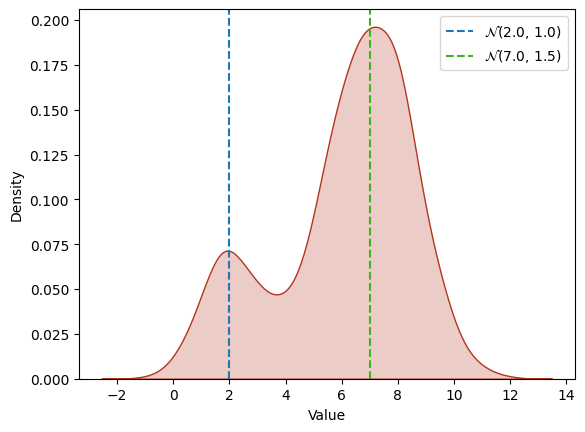

In [32]:
plt.figure()
sns.kdeplot(y_simulated, fill=True, color="#b4351f")
plt.axvline(x=mu_actual[0], color="#1f77b4", linestyle="--", linewidth=1.5, label=r'$\mathcal{N}$'+'('+str(mu_actual[0])+', '+str(sigma_actual[0])+')')
plt.axvline(x=mu_actual[1], color="#3db41f", linestyle="--", linewidth=1.5, label=r'$\mathcal{N}$'+'('+str(mu_actual[1])+', '+str(sigma_actual[1])+')')

plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(loc="upper right")
plt.show()

In [242]:
# 2. Define the Target Log Prob function (Unnormalized Joint Posterior)
def target_log_prob(mu, sigma, theta):
    # Prior distributions

    # # Pri_mu = [tfd.Normal(loc=0.0, scale=10.0), tfd.Normal(loc=0.0, scale=10.0)]
    # Pri_mu = tfd.JointDistributionSequential([
    #             tfd.Normal(loc=0.0, scale=10.0),
    #             tfd.Normal(loc=0.0, scale=10.0)
    #         ])
    # # Pri_sigma = [tfd.Exponential(rate=1), tfd.Exponential(rate=1)]
    # Pri_sigma = tfd.JointDistributionSequential([
    #             tfd.Exponential(rate=1),
    #             tfd.Exponential(rate=1)
    #         ])

    # Pri_theta = tfd.Beta(concentration0=2,concentration1=2)

    Pri_mu = tfd.Independent(
        tfd.Normal(loc=tf.zeros(2, dtype=tf.float32), scale=10.0),
        reinterpreted_batch_ndims=1
    )
    Pri_sigma = tfd.Independent(
        tfd.Exponential(rate=tf.ones(2, dtype=tf.float32)),
        reinterpreted_batch_ndims=1
    )
    Pri_theta = tfd.Beta(
        concentration0=tf.constant(2.0, dtype=tf.float32),
        concentration1=tf.constant(2.0, dtype=tf.float32)
    )
    
    # Likelihood function
    probs = tf.stack([theta, 1.0 - theta], axis=-1)
    # likelihood = theta * tfd.Normal(loc=mu[0], scale=sigma[0])   +    (1-theta) * tfd.Normal(loc=mu[1], scale=sigma[1])
    likelihood = tfd.MixtureSameFamily(
        mixture_distribution=tfd.Categorical(probs=probs),
        components_distribution=tfd.Normal(loc=mu, scale=sigma),
    )

    # Compute the log likelihood for observed data x
    log_likelihood = tf.reduce_sum(likelihood.log_prob(y_simulated))

    
    # Return total joint log likelihood (Priors + Likelihood)
    prior_mu_lp = Pri_mu.log_prob(mu)
    prior_sigma_lp = Pri_sigma.log_prob(sigma)
    prior_theta_lp = Pri_theta.log_prob(theta)

    # return (Pri_mu.log_prob(mu) + Pri_sigma.log_prob(sigma) + Pri_theta.log_prob(theta) + log_likelihood)
    return prior_mu_lp + prior_sigma_lp + prior_theta_lp + log_likelihood


    

In [243]:
num_results = 8000
num_burnin_steps = 2000

In [244]:
bijectors = [
    tfb.Identity(),
    tfb.Exp(),
    tfb.Sigmoid()
]

hmc_kernel = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn=target_log_prob,
    step_size=0.01,
    num_leapfrog_steps=3
)

# Constrain the parameter space during sampling
transformed_hmc = tfp.mcmc.TransformedTransitionKernel(
    inner_kernel=hmc_kernel,
    bijector=bijectors
)

adaptive_hmc = tfp.mcmc.SimpleStepSizeAdaptation(
    inner_kernel=transformed_hmc,
    num_adaptation_steps=int(num_burnin_steps * 0.8)
)

In [245]:
@tf.function(autograph=False, jit_compile=False)
def run_chain():
    # Initial state for parameters [slope, intercept]
    # initial_state = [[tf.constant(0.0), tf.constant(0.0)], [tf.constant(0.0), tf.constant(0.0)], tf.constant(0.0)]
    initial_state = [
                        tf.constant([0.0, 0.0]),  # or tf.zeros([2]) if mu is 2D
                        tf.constant([1.0, 1.0]),  # or tf.zeros([2]) if sigma is 2D
                        tf.constant(0.5)   # theta
                    ]
    samples, is_accepted = tfp.mcmc.sample_chain(
        num_results=num_results,
        num_burnin_steps=num_burnin_steps,
        current_state=initial_state,
        kernel=adaptive_hmc,
        trace_fn=lambda _, pkr: pkr.inner_results.inner_results.is_accepted
    )
    return samples

In [246]:
mu_samples, sigma_samples, theta_samples = run_chain()

In [248]:
print("Posterior Mean Mu1:", tf.reduce_mean(mu_samples[::,0]).numpy())
print("Posterior Mean Sigma1:", tf.reduce_mean(sigma_samples[::,0]).numpy())

print("Posterior Mean Mu2:", tf.reduce_mean(mu_samples[::,1]).numpy())
print("Posterior Mean Sigma2:", tf.reduce_mean(sigma_samples[::,1]).numpy())

print("Posterior Mean Theta:", tf.reduce_mean(theta_samples).numpy())

Posterior Mean Mu1: 7.0380607
Posterior Mean Sigma1: 1.5051943
Posterior Mean Mu2: 2.0413067
Posterior Mean Sigma2: 1.0041752
Posterior Mean Theta: 0.8046007


In [249]:
print(mu_actual[0], sigma_actual[0])
print(mu_actual[1], sigma_actual[1])
print(true_theta)

2.0 1.0
7.0 1.5
0.2


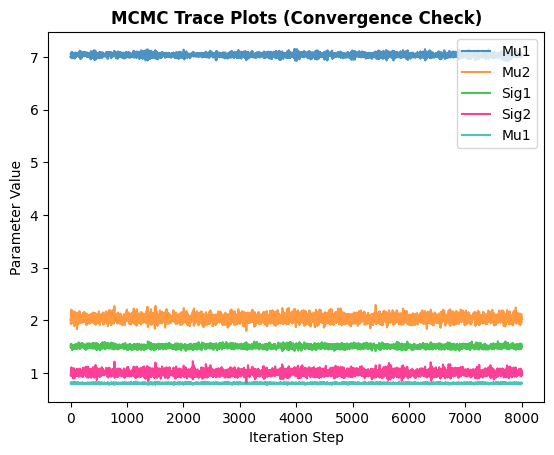

In [252]:
plt.figure()
plt.plot(2, 2, 1)
plt.plot(mu_samples[::,0].numpy(), label="Mu1", alpha=0.8, color="#1f77b4")
plt.plot(mu_samples[::,1].numpy(), label="Mu2", alpha=0.8, color="#ff7f0e")

plt.plot(sigma_samples[::,0].numpy(), label="Sig1", alpha=0.8, color="#1fb42b")
plt.plot(sigma_samples[::,1].numpy(), label="Sig2", alpha=0.8, color="#ff0e7e")

plt.plot(theta_samples.numpy(), label="Mu1", alpha=0.8, color="#1fb4a8")

plt.title("MCMC Trace Plots (Convergence Check)", fontsize=12, fontweight="bold")
plt.xlabel("Iteration Step")
plt.ylabel("Parameter Value")
plt.legend(loc="upper right")
plt.show()

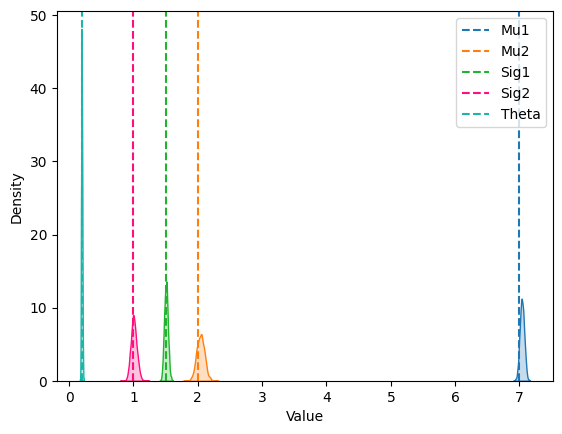

In [265]:
plt.figure()
sns.kdeplot(mu_samples[::,0].numpy(), fill=True, color="#1f77b4")
plt.axvline(x=mu_actual[1], color="#1f77b4", linestyle="--", linewidth=1.5, label='Mu1')

sns.kdeplot(mu_samples[::,1].numpy(), fill=True, color="#ff7f0e")
plt.axvline(x=mu_actual[0], color="#ff7f0e", linestyle="--", linewidth=1.5, label='Mu2')

sns.kdeplot(sigma_samples[::,0].numpy(), fill=True, color="#1fb42b")
plt.axvline(x=sigma_actual[1], color="#1fb42b", linestyle="--", linewidth=1.5, label='Sig1')

sns.kdeplot(sigma_samples[::,1].numpy(), fill=True, color="#ff0e7e")
plt.axvline(x=sigma_actual[0], color="#ff0e7e", linestyle="--", linewidth=1.5, label='Sig2')

sns.kdeplot(1-theta_samples.numpy(), fill=True, color="#1fb4a8")
plt.axvline(x=true_theta, color="#1fb4a8", linestyle="--", linewidth=1.5, label='Theta')


plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(loc="upper right")
plt.show()

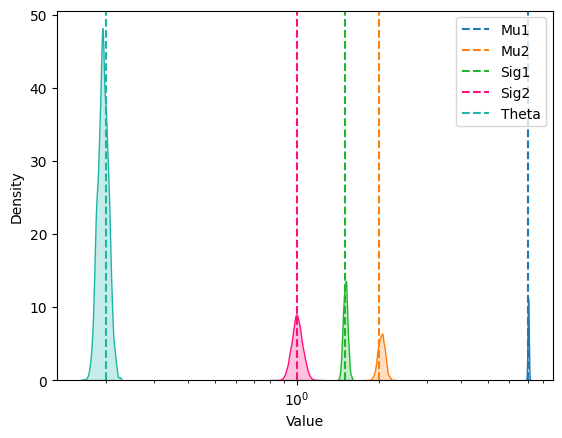

In [266]:
plt.figure()
sns.kdeplot(mu_samples[::,0].numpy(), fill=True, color="#1f77b4")
plt.axvline(x=mu_actual[1], color="#1f77b4", linestyle="--", linewidth=1.5, label='Mu1')

sns.kdeplot(mu_samples[::,1].numpy(), fill=True, color="#ff7f0e")
plt.axvline(x=mu_actual[0], color="#ff7f0e", linestyle="--", linewidth=1.5, label='Mu2')

sns.kdeplot(sigma_samples[::,0].numpy(), fill=True, color="#1fb42b")
plt.axvline(x=sigma_actual[1], color="#1fb42b", linestyle="--", linewidth=1.5, label='Sig1')

sns.kdeplot(sigma_samples[::,1].numpy(), fill=True, color="#ff0e7e")
plt.axvline(x=sigma_actual[0], color="#ff0e7e", linestyle="--", linewidth=1.5, label='Sig2')

sns.kdeplot(1-theta_samples.numpy(), fill=True, color="#1fb4a8")
plt.axvline(x=true_theta, color="#1fb4a8", linestyle="--", linewidth=1.5, label='Theta')


plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(loc="upper right")
plt.xscale('log')
plt.show()